# **Import**

In [175]:


# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Operating system (for creating folders)
import os

# Random seed for reproducibility
import random

# Preprocessing and model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Create folder if it doesn't exist
os.makedirs("plots", exist_ok=True)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [176]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [177]:
file_path='/content/drive/MyDrive/CSE422/E-commerce Shipping Dataset.csv'

# **Dataset description**

In [178]:
df = pd.read_csv(file_path)
from IPython.display import display
print("Dataset Preview:")
display(df.head(10))
print("\nRandom 5 rows:")
display(df.sample(5))

Dataset Preview:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1



Random 5 rows:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
7785,7786,B,Road,4,3,240,3,medium,M,6,4964,0
6884,6885,A,Ship,6,3,139,6,medium,F,8,1284,1
383,384,F,Ship,4,5,175,2,low,M,40,1270,1
5136,5137,D,Ship,4,1,273,4,low,M,1,4857,0
6214,6215,C,Ship,6,5,295,4,medium,M,1,1159,0


In [179]:
df = df.drop('ID', axis=1)
for col in df.columns:
    print(repr(col))

'Warehouse_block'
'Mode_of_Shipment'
'Customer_care_calls'
'Customer_rating'
'Cost_of_the_Product'
'Prior_purchases'
'Product_importance'
'Gender'
'Discount_offered'
'Weight_in_gms'
'Reached.on.Time_Y.N'


In [180]:
df.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [181]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Warehouse_block      10999 non-null  object
 1   Mode_of_Shipment     10999 non-null  object
 2   Customer_care_calls  10999 non-null  int64 
 3   Customer_rating      10999 non-null  int64 
 4   Cost_of_the_Product  10999 non-null  int64 
 5   Prior_purchases      10999 non-null  int64 
 6   Product_importance   10999 non-null  object
 7   Gender               10999 non-null  object
 8   Discount_offered     10999 non-null  int64 
 9   Weight_in_gms        10999 non-null  int64 
 10  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 945.4+ KB


In [182]:
summary = pd.DataFrame({
    'Count': df['Reached.on.Time_Y.N'].value_counts(),
    'Percentage (%)': df['Reached.on.Time_Y.N'].value_counts(normalize=True) * 100
})

print(summary)

                     Count  Percentage (%)
Reached.on.Time_Y.N                       
1                     6563       59.669061
0                     4436       40.330939


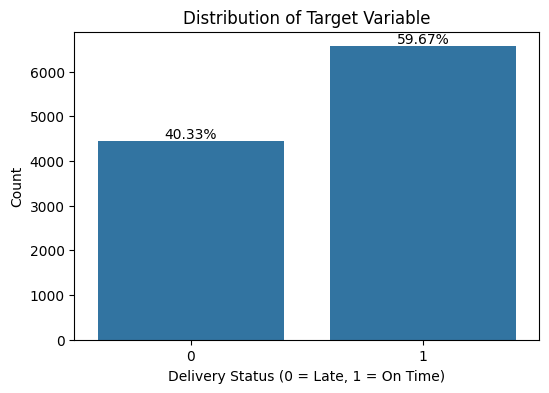

In [183]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Reached.on.Time_Y.N', data=df)

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Target Variable")
plt.xlabel("Delivery Status (0 = Late, 1 = On Time)")
plt.ylabel("Count")
plt.savefig("plots/target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [184]:
df.isnull().sum()

,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0
Weight_in_gms,0


In [185]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')
#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)
numerical_data.describe().T

There are 7 numerical features: 

['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0
Reached.on.Time_Y.N,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


In [186]:
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')
#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} Categorical features:', '\n')
print(categorical_features)
categorical_data.describe().T

There are 4 Categorical features: 

['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


,count,unique,top,freq
Warehouse_block,10999,5,F,3666
Mode_of_Shipment,10999,3,Ship,7462
Product_importance,10999,3,low,5297
Gender,10999,2,F,5545


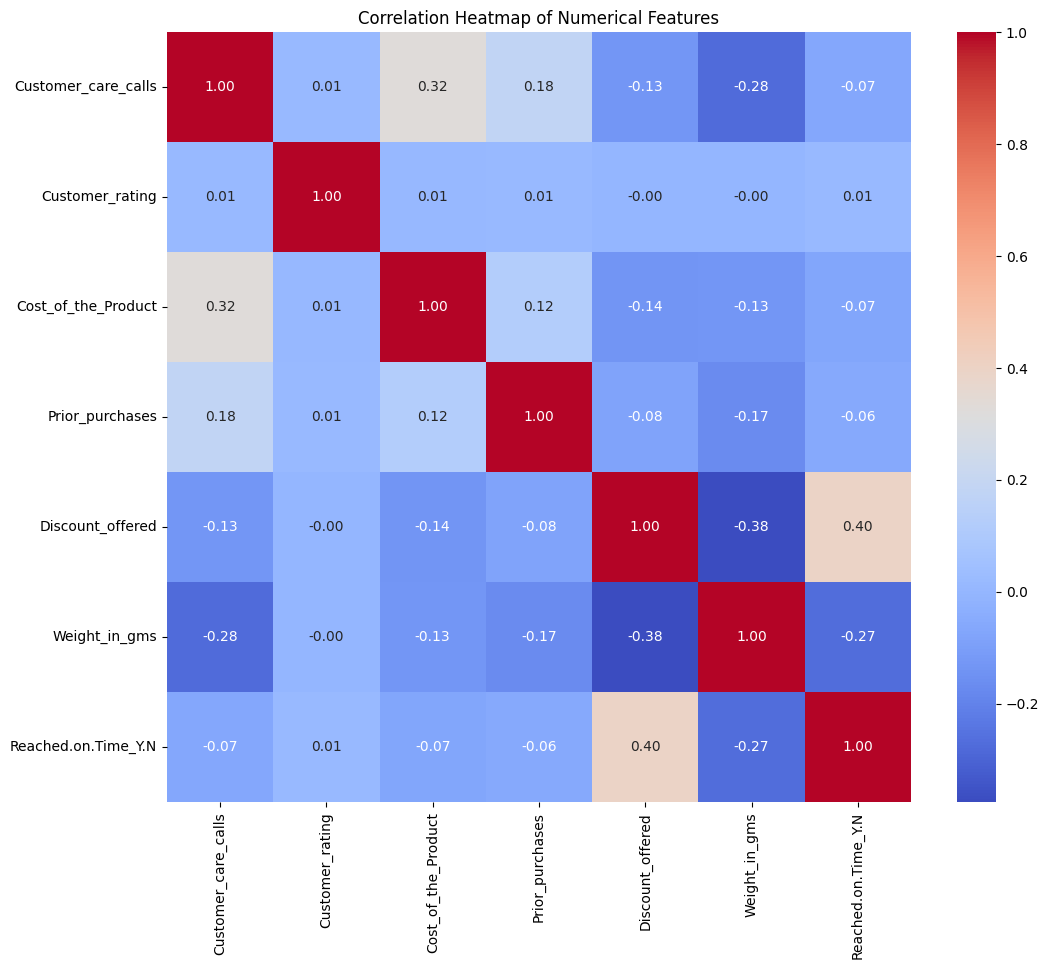

In [187]:

# Plot heatmap for correlation
# Select only numerical features
numerical_data = df.select_dtypes(include='number')
# Compute correlation
corr_matrix = numerical_data.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


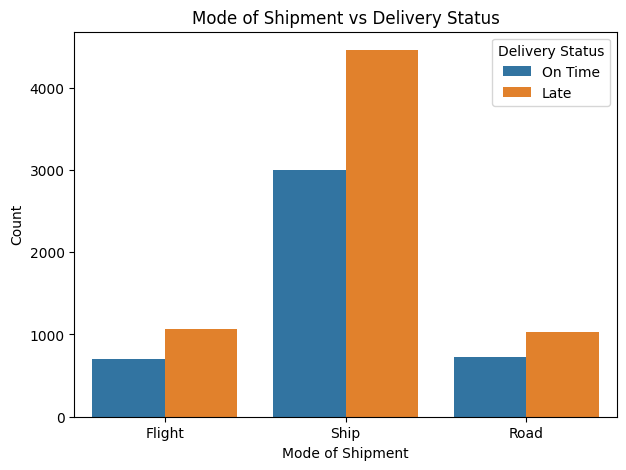

In [188]:
plt.figure(figsize=(7,5))

sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df)

plt.title("Mode of Shipment vs Delivery Status")
plt.xlabel("Mode of Shipment")
plt.ylabel("Count")
plt.legend(title="Delivery Status", labels=["On Time", "Late"])

plt.savefig("plots/mode_of_shipment_vs_delivery.png", dpi=300, bbox_inches='tight')

plt.show()

# **Data Preprocessing**

In [189]:


#CHECK MISSING VALUES

print("Missing values:\n", df.isnull().sum())

#DROP ID (if exists)

if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

#FIX & ENCODE PRODUCT_IMPORTANCE

if 'Product_importance' in df.columns:
    # Convert to lowercase first (avoid mapping error)
    df['Product_importance'] = df['Product_importance'].str.lower()

    df['Product_importance'] = df['Product_importance'].map({
        'low': 0,
        'medium': 1,
        'high': 2
    })

    # Check if mapping worked
    print("\nMissing after encoding Product_importance:",
          df['Product_importance'].isnull().sum())


#ONE-HOT ENCODING (ONLY IF COLUMNS EXIST)

categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Gender']

existing_cols = [col for col in categorical_cols if col in df.columns]

if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)
    print("\nOne-hot encoding applied on:", existing_cols)
else:
    print("\nCategorical columns already encoded. Skipping step.")

#FEATURE SCALING

scaler = StandardScaler()

target_col = 'Reached.on.Time_Y.N'

feature_cols = [col for col in df.columns if col != target_col]

df[feature_cols] = scaler.fit_transform(df[feature_cols])


#JUST CHECK

print("\nFinal Data Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

Missing values:
 Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Missing after encoding Product_importance: 0

One-hot encoding applied on: ['Warehouse_block', 'Mode_of_Shipment', 'Gender']

Final Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_care_calls    10999 non-null  float64
 1   Customer_rating        10999 non-null  float64
 2   Cost_of_the_Product    10999 non-null  float64
 3   Prior_purchases        10999 non-null  float64
 4   Product_importance     10999 non-null  float64
 5   Discount_offered       10999 non-null  float64
 6   Weight_in_gms        

In [190]:
df.isnull().sum()

,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Discount_offered,0
Weight_in_gms,0
Reached.on.Time_Y.N,0
Warehouse_block_B,0
Warehouse_block_C,0


# **Dataset Splitting**

In [191]:


X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']


#Train-Test Split (80-20, Stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 3Validation Split (from training set)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,   # 10% of training = validation
    random_state=42,
    stratify=y_train
)


#Check Sizes

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7919, 14)
Validation set: (880, 14)
Test set: (2200, 14)


# **Model Training**

# KNN

In [192]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)

print("Best KNN Params:", knn_grid.best_params_)

y_pred = knn_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best KNN Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Accuracy: 0.6272727272727273
              precision    recall  f1-score   support

           0       0.53      0.58      0.56       887
           1       0.70      0.66      0.68      1313

    accuracy                           0.63      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.63      0.63      2200



# DECISION TREE

In [193]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)

y_pred_dt = grid_dt.predict(X_test)

print("Decision Tree Best Params:", grid_dt.best_params_)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt, average='macro'))

print(classification_report(y_test, y_pred_dt))

Decision Tree Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree Accuracy: 0.6781818181818182
Decision Tree F1 Score: 0.6746878038836963
              precision    recall  f1-score   support

           0       0.56      0.97      0.71       887
           1       0.96      0.48      0.64      1313

    accuracy                           0.68      2200
   macro avg       0.76      0.73      0.67      2200
weighted avg       0.80      0.68      0.67      2200



# LOGISTIC REGRESSION

In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],  # Expanded for better search
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Params: {'C': 100, 'solver': 'liblinear'}
Best CV Score: 0.624963866963981
Accuracy: 0.6377272727272727
F1 Score: 0.627702864675066

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



# NEURAL NETWORK

In [197]:
# Set seeds for reproducibility
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

# Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_train)), activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
print("Training Neural Network...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test), axis=1)
print("NEURAL NETWORK RESULTS")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Reached', 'Reached']))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network...
Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6297 - loss: 0.5875 - val_accuracy: 0.6553 - val_loss: 0.5389
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6600 - loss: 0.5403 - val_accuracy: 0.6490 - val_loss: 0.5325
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6601 - loss: 0.5330 - val_accuracy: 0.6465 - val_loss: 0.5270
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6608 - loss: 0.5291 - val_accuracy: 0.6540 - val_loss: 0.5244
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6687 - loss: 0.5251 - val_accuracy: 0.6585 - val_loss: 0.5226
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6709 - loss: 0.5225 - val_accuracy: 0.6572 - val_loss: 0.5211
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6658 - loss: 0.5214 - val_accuracy: 0.6585 - val_loss: 0.5207
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6693 - los

#  Unsupervised learning problem, apply Kmeans and showcase the clusters


In [198]:
# Step 1: Create a copy of your preprocessed dataframe
df_cluster = df.copy()  # df already has scaled features and encoded categoricals

# Step 2: Drop the target column (not used for clustering)
X_clustering = df_cluster.drop('Reached.on.Time_Y.N', axis=1)
y_clustering = df_cluster['Reached.on.Time_Y.N']  # Keep for evaluation only

# Step 3: Your data is ALREADY scaled and encoded from preprocessing!
# No need to scale again!

print("Using preprocessed data for clustering")
print(f"   Features shape: {X_clustering.shape}")
print(f"   Number of samples: {len(X_clustering)} (using ALL data)")
print(f"   Features already scaled: Yes")
print(f"   Categorical features encoded: Yes")

# Step 4: Apply K-Means directly
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_clustering)

# Evaluate
sil_score = silhouette_score(X_clustering, cluster_labels)
ari_score = adjusted_rand_score(y_clustering, cluster_labels)

print(f"\nClustering Results:")
print(f"   Silhouette Score: {sil_score:.4f}")
print(f"   Adjusted Rand Index: {ari_score:.4f}")

# Show cluster distribution
cluster_dist = pd.crosstab(y_clustering, cluster_labels)
print("\nTrue Class vs Cluster Assignment:")
print(cluster_dist)

Using preprocessed data for clustering
   Features shape: (10999, 14)
   Number of samples: 10999 (using ALL data)
   Features already scaled: Yes
   Categorical features encoded: Yes

Clustering Results:
   Silhouette Score: 0.1799
   Adjusted Rand Index: -0.0007

True Class vs Cluster Assignment:
col_0                   0     1     2     3
Reached.on.Time_Y.N                        
0                     739  2230   729   738
1                    1094  3269  1104  1096


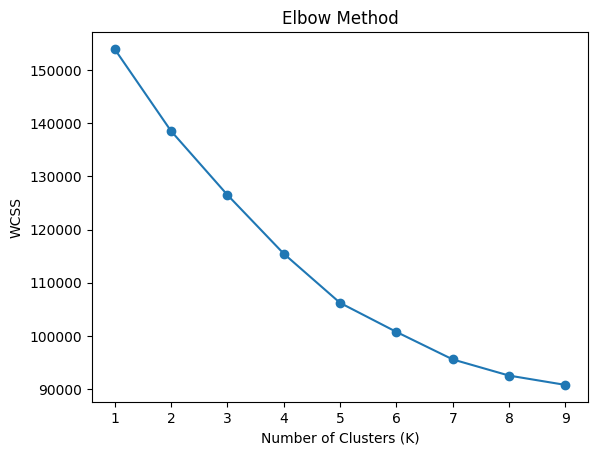

In [199]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Use your clustering dataset (already preprocessed)
X_kmeans = X_clustering

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_kmeans)
    wcss.append(km.inertia_)

plt.figure()
plt.plot(range(1, 10), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.savefig("elbow_method.png", dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


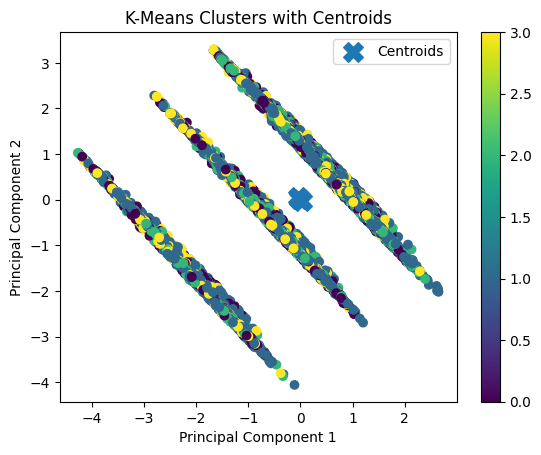

In [200]:
from sklearn.decomposition import PCA
# Transform cluster centers to PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)

# Plot centroids
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            marker='X', s=200, label='Centroids')

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.colorbar(scatter)

plt.savefig("kmeans_clusters_with_centroids.png", dpi=300, bbox_inches='tight')
plt.show()

# Model Selection & Comparison Analysis

In [201]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Neural Network prediction
y_pred_nn = np.argmax(model.predict(X_test), axis=1)

# Logistic Regression
y_pred_lr = grid.predict(X_test)

# KNN
y_pred_knn = knn_grid.predict(X_test)

# Decision Tree (ADDED)
y_pred_dt = grid_dt.predict(X_test)

# Store everything
results = []

models = {
    "Neural Network": y_pred_nn,
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt   # ✅ added
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append([name, acc, precision, recall, f1])

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print(df_results)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                 Model  Accuracy  Precision    Recall  F1 Score
0       Neural Network  0.657727   0.693499  0.688745  0.657481
1  Logistic Regression  0.637727   0.627000  0.629559  0.627703
2                  KNN  0.627273   0.617155  0.619886  0.617707
3        Decision Tree  0.678182   0.758554  0.725450  0.674688


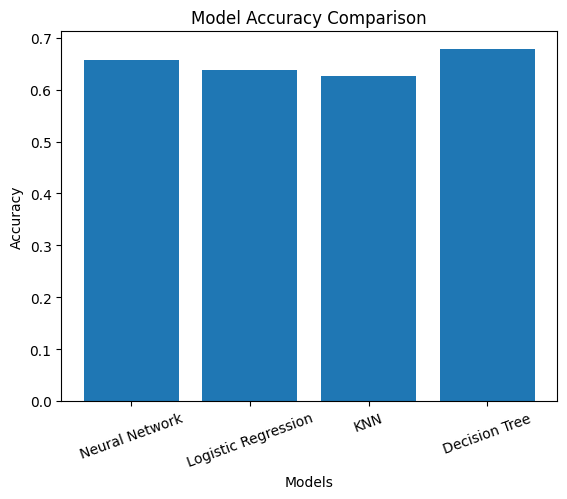

In [202]:

plt.figure()
plt.bar(df_results["Model"], df_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

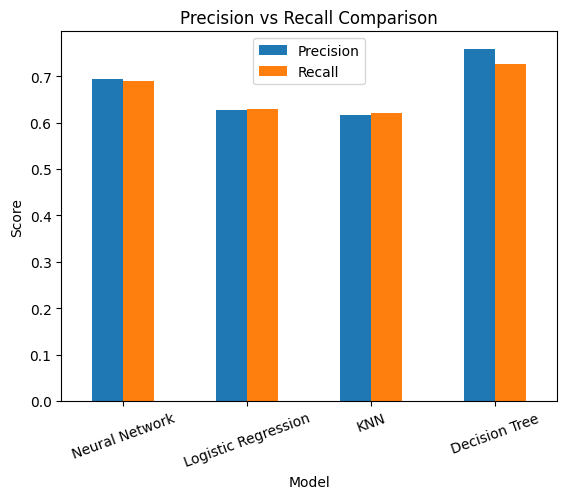

In [203]:
df_results.set_index("Model")[["Precision", "Recall"]].plot(kind='bar')

plt.title("Precision vs Recall Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.savefig("precision_vs_recall.png", dpi=300, bbox_inches='tight')
plt.show()

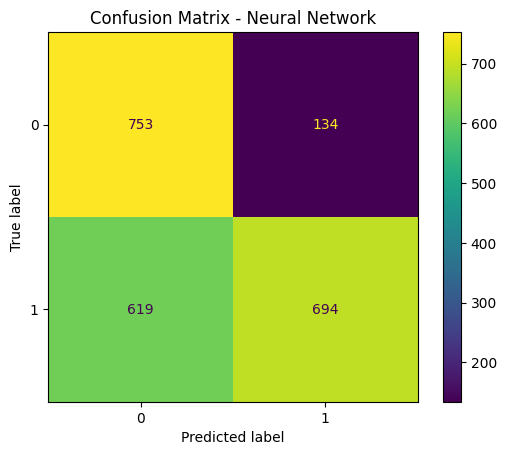

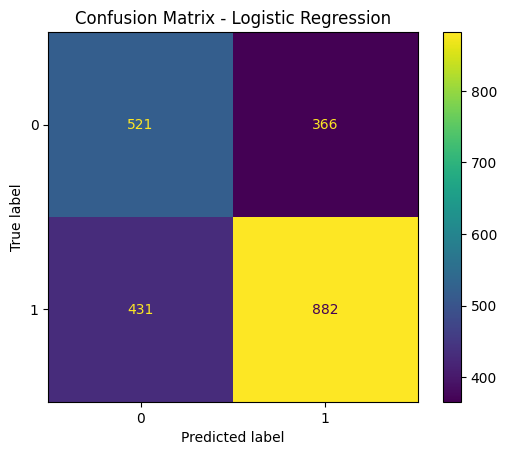

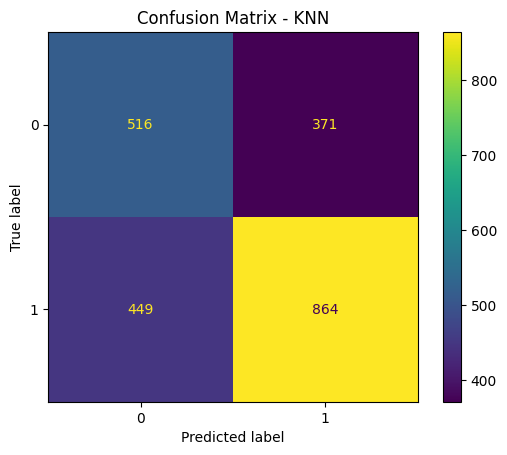

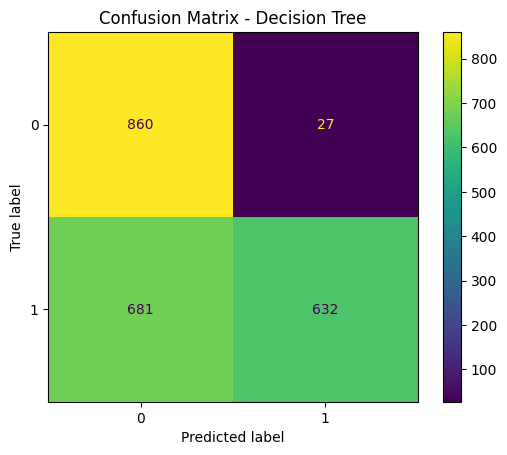

In [204]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")

    filename = f"confusion_matrix_{name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


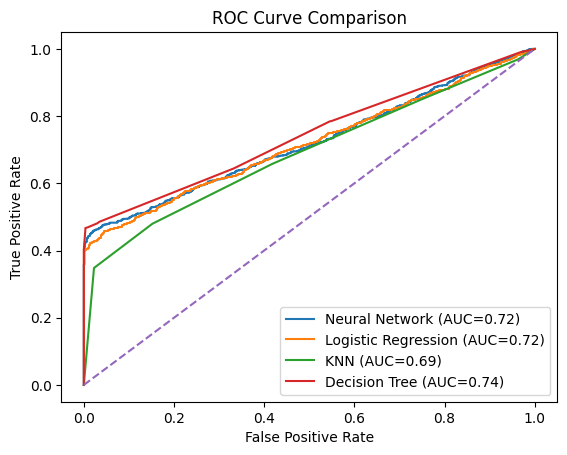

In [205]:
from sklearn.metrics import roc_curve, auc

plt.figure()

# Neural Network (probabilities)
y_prob_nn = model.predict(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr, tpr, label=f"Neural Network (AUC={auc(fpr, tpr):.2f})")

# Logistic Regression
y_prob_lr = grid.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc(fpr, tpr):.2f})")

# KNN
y_prob_knn = knn_grid.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr, tpr, label=f"KNN (AUC={auc(fpr, tpr):.2f})")

#Decision Tree
y_prob_dt = grid_dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC={auc(fpr, tpr):.2f})")

# Plot formatting
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()